#### How well do **jobs** and **skills** pay for ***Data Analyst***?

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Accessing raw data from data access function
from data_jobs.data_access import load_data

# Cleaning the data with cleaning function/s
from data_jobs.data_process import clean_date, clean_skills


df = load_data()
df = clean_date(df)
df = clean_skills(df)

print("Lib/s loaded and data ready")

c:\Users\hersh\anaconda3\envs\data_jobs_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Lib/s loaded and data ready


In [2]:
# filtering for country of interest and yearly salary not na.
df_IN = (df.query('job_country == "India"').dropna(subset=['salary_year_avg']))

In [3]:
# job titles by popularity
job_titles = df_IN['job_title_short'].value_counts().index[:6].tolist()

job_titles

['Data Engineer',
 'Data Analyst',
 'Data Scientist',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Software Engineer']

In [13]:
df_IN_top6 = df_IN[df_IN['job_title_short'].isin(job_titles)]


In [15]:
# creating a list of sorted job titles by their median salary.

job_order = df_IN_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index
job_order

Index(['Data Engineer', 'Senior Data Engineer', 'Data Scientist',
       'Data Analyst', 'Machine Learning Engineer', 'Software Engineer'],
      dtype='str', name='job_title_short')

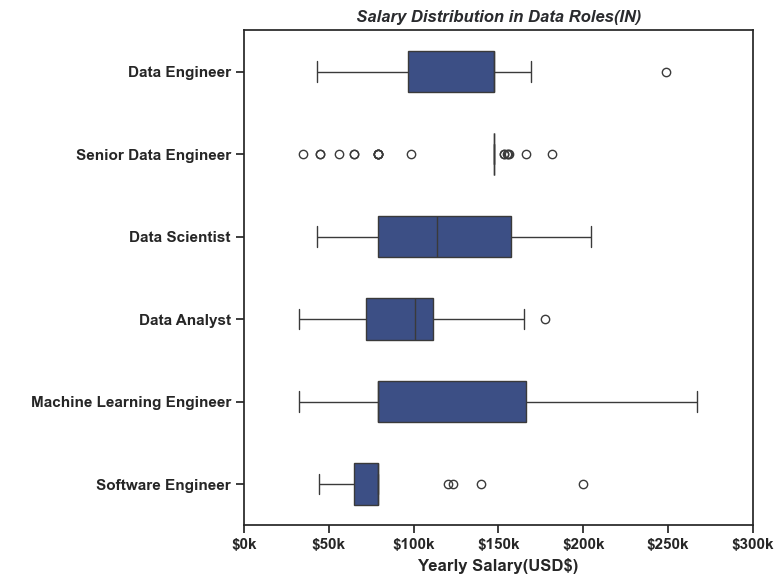

In [6]:
plt.rcParams.update({ 'font.weight': 'bold',
                     'font.size': 12,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'axes.labelcolor': "#2A2B2E",
    'text.color': '#2A2B2E',
    'axes.titlecolor': '#2A2B2E',
    'xtick.color': "#2A2B2E",
    'ytick.color': '#2A2B2E',
    'axes.titlesize':16,
    'axes.labelsize':10
    })

plt.figure(figsize=(8, 6))
sns.set_theme(style='ticks')

sns.boxplot(data=df_IN_top6, x='salary_year_avg', 
            y='job_title_short', order=job_order, 
            width=.5, color="#304991")

plt.title('Salary Distribution in Data Roles(IN)', fontstyle='italic')
plt.xlim(0, 300000)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x , pos:f'${int(x/1000)}k'))

plt.xlabel('Yearly Salary(USD$)')
plt.ylabel(' ')

plt.tight_layout()
plt.show()

#### Investigating ***Median Salary*** Vs ***Skill*** for **Data Analyst**

In [7]:
# sorting df by job role and country of interest
df_DA_IN = df.query('job_title_short == "Data Analyst" and job_country == "India"').copy()

df_DA_IN.dropna(subset=['salary_year_avg'], inplace=True)

In [8]:
df_DA_IN = df_DA_IN.explode('job_skills')

df_DA_IN[['salary_year_avg', 'job_skills']].head()

,salary_year_avg,job_skills
11412,50400.0,python
11412,50400.0,sql
11412,50400.0,aws
11412,50400.0,azure
11412,50400.0,excel


In [9]:
# grouping top 10 high paying skills in Data Analytics
df_DA_top_pay = (df_DA_IN.groupby('job_skills')['salary_year_avg']
                 .agg(['count','median'])
                 .sort_values(by='median', ascending=False)
                 .head(10)
)


In [10]:
# grouping top 10 most popular skills, sorting them by salary high to low.
df_DA_skills = (df_DA_IN.groupby('job_skills')['salary_year_avg']
                 .agg(['count','median'])
                 .sort_values(by='count', ascending=False)
                 .head(10)
                 .sort_values(by='median', ascending=False)
)
df_DA_skills

,count,median
job_skills,,
spark,11,111175.0
power bi,17,111175.0
tableau,20,108087.5
excel,39,98500.0
sql,46,96050.0
python,36,96050.0
azure,15,93600.0
r,18,79200.0
aws,12,79200.0


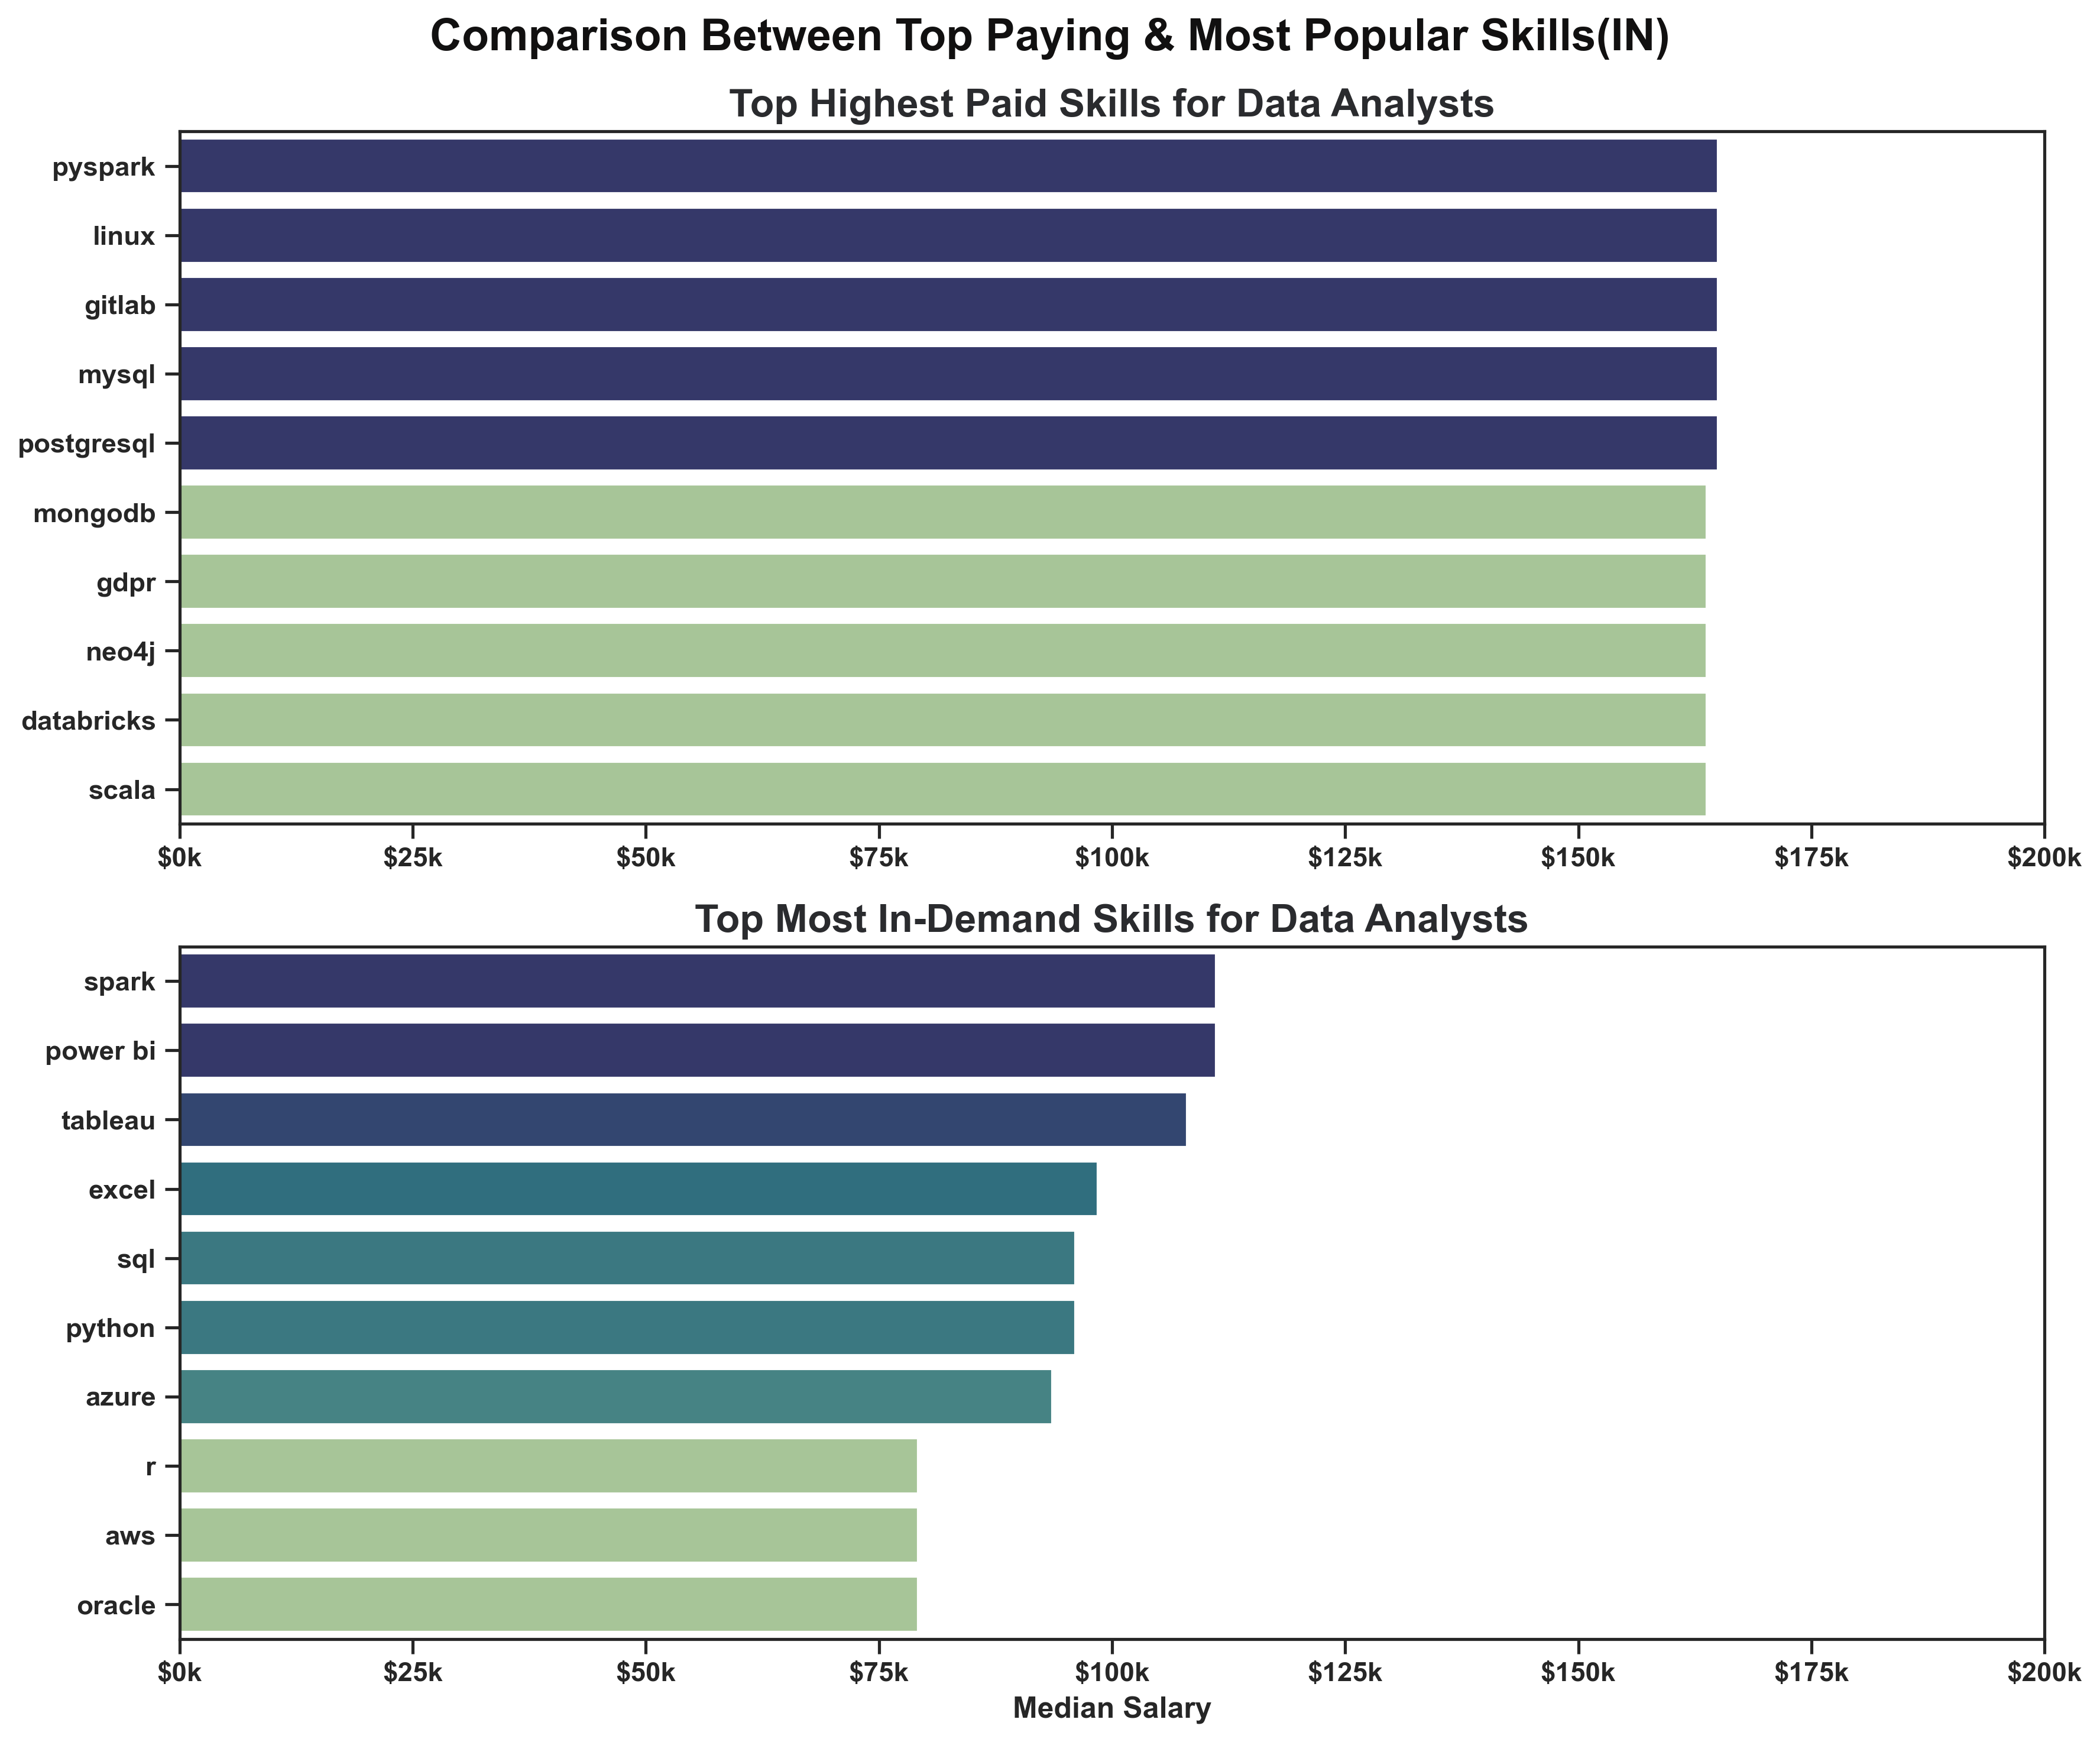

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10), dpi=300)

sns.set_theme(style='ticks')

sns.barplot(df_DA_top_pay, x='median', y= df_DA_top_pay.index, ax= ax[0], hue='median', palette='crest')
ax[0].legend().remove()
ax[0].set_title('Top Highest Paid Skills for Data Analysts', fontsize=16)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'${int(x/1000)}k'))
ax[0].set_xlim(0, 200000)
ax[0].set_xlabel('')
ax[0].set_ylabel('')

sns.barplot(df_DA_skills, x='median', y= df_DA_skills.index, ax= ax[1], hue='median', palette= 'crest')
ax[1].legend().remove()
ax[1].set_title('Top Most In-Demand Skills for Data Analysts', fontsize=16)
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'${int(x/1000)}k'))
ax[1].set_xlim(0, 200000)
ax[1].set_xlabel('Median Salary')
ax[1].set_ylabel('')


plt.suptitle('Comparison Between Top Paying & Most Popular Skills(IN)', fontsize=18, fontweight='bold',color="#111010")

fig.tight_layout()
plt.show()